In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [21]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [22]:
tickers = ["TSLA", "BND", "SPY"]

start_date = "2015-01-01"
end_date = "2026-07-01"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    group_by="ticker",
    auto_adjust=False,
    threads=False,
    progress=False
)

data.head()

Ticker             SPY                                                  \
Price             Open        High         Low       Close   Adj Close   
Date                                                                     
2015-01-02  206.380005  206.880005  204.179993  205.429993  169.687881   
2015-01-05  204.169998  204.369995  201.350006  201.720001  166.623337   
2015-01-06  202.089996  202.720001  198.860001  199.820007  165.053894   
2015-01-07  201.419998  202.720001  200.880005  202.309998  167.110687   
2015-01-08  204.009995  206.160004  203.990005  205.899994  170.076065   

Ticker                      TSLA                                              \
Price          Volume       Open       High        Low      Close  Adj Close   
Date                                                                           
2015-01-02  121465900  14.858000  14.883333  14.217333  14.620667  14.620667   
2015-01-05  169632600  14.303333  14.433333  13.810667  14.006000  14.006000   
2015-01-06  209151400  14.004000  14.280000  13.614000  14.085333  14.085333   
2015-01-07  125346700  14.223333  14.318667  13.985333  14.063333  14.063333   
2015-01-08  147217800  14.187333  14.253333  14.000667  14.041333  14.041333   

Ticker                      BND                                              \
Price         Volume       Open       High        Low      Close  Adj Close   
Date                                                                          
2015-01-02  71466000  82.430000  82.690002  82.419998  82.650002  59.205673   
2015-01-05  80527500  82.739998  82.919998  82.699997  82.889999  59.377571   
2015-01-06  93928500  83.029999  83.379997  83.029999  83.129997  59.549477   
2015-01-07  44526000  83.139999  83.279999  83.050003  83.180000  59.585308   
2015-01-08  51637500  83.110001  83.110001  82.970001  83.050003  59.492188   

Ticker               
Price        Volume  
Date                 
2015-01-02  2218800  
2015-01-05  5820100  
2015-01-06  3887600  
2015-01-07  2433400  
2015-01-08  1873400

In [23]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd()
processed_dir = project_root / "data" / "processed"

print("Current folder:", project_root)
print("Files found:", list(processed_dir.glob("*")))

tsla = pd.read_csv(
    processed_dir / "TSLA_cleaned.csv",
    index_col="Date",
    parse_dates=True
)

tsla.head()

Current folder: /Users/mac/portfolio-optimization/notebooks
Files found: [PosixPath('/Users/mac/portfolio-optimization/notebooks/data/processed/TSLA_cleaned.csv'), PosixPath('/Users/mac/portfolio-optimization/notebooks/data/processed/BND_cleaned.csv'), PosixPath('/Users/mac/portfolio-optimization/notebooks/data/processed/SPY_cleaned.csv')]


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000
2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500
2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500
2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000
2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500


In [24]:
import pandas as pd
import os

print("Current folder:", os.getcwd())
print("Processed files:", os.listdir("data/processed"))

tsla = pd.read_csv(
    "data/processed/TSLA_cleaned.csv",
    index_col="Date",
    parse_dates=True
)

tsla.head()

Current folder: /Users/mac/portfolio-optimization/notebooks
Processed files: ['TSLA_cleaned.csv', 'BND_cleaned.csv', 'SPY_cleaned.csv']


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000
2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500
2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500
2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000
2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500


In [25]:
import pandas as pd

tsla = pd.read_csv(
    "data/processed/TSLA_cleaned.csv",
    index_col="Date",
    parse_dates=True
)

tsla.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000
2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500
2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500
2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000
2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500


In [26]:
tsla_price = tsla["Adj Close"]

In [27]:
train = tsla_price[:"2024-12-31"]
test = tsla_price["2025-01-01":]

In [28]:
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 2516
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -8180.940
Date:                Sat, 04 Jul 2026   AIC                          16373.881
Time:                        14:00:27   BIC                          16408.861
Sample:                             0   HQIC                         16386.576
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0050      0.012     -0.410      0.682      -0.029       0.019
ar.L2          0.0100      0.011      0.947      0.344      -0.011       0.031
ar.L3         -0.0092      0.013     -0.728      0.4

In [29]:
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/mac/portfolio-optimization/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


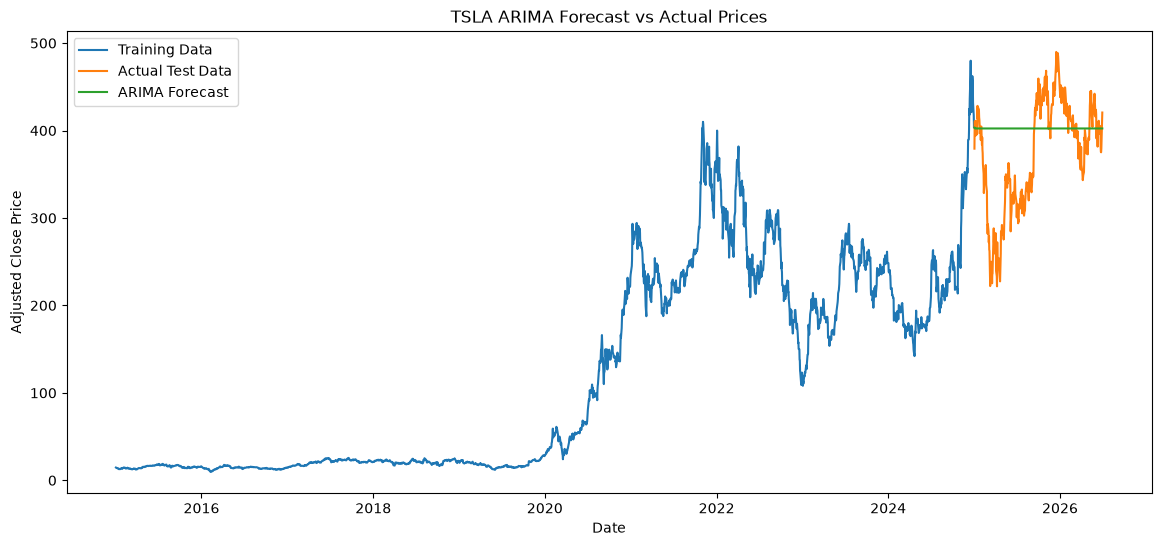

In [30]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(forecast.index, forecast, label="ARIMA Forecast")

plt.title("TSLA ARIMA Forecast vs Actual Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.show()

In [31]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

metrics = pd.DataFrame({
    "Model": ["ARIMA(5,1,0)"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape]
})

metrics

,Model,MAE,RMSE,MAPE
0,"ARIMA(5,1,0)",54.048572,69.814015,17.070313


In [32]:
metrics.to_csv("../data/processed/arima_metrics.csv", index=False)